# 0. Carga de datos brutos

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
import geopandas as gpd
from shapely import wkt
from google.cloud import bigquery
import unicodedata

from pre_procesado.common_pipeline import run_global_pipeline
from utils_entrenamiento import walk_forward_split

from pre_procesado.non_linear_pipeline import build_tree_pipeline
from utils_entrenamiento import evaluate_classification, aggregate_fold_metrics
from utils_entrenamiento import plot_confusion_matrix 

import shap
from tqdm.auto import tqdm 

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

c:\Users\Yannis\anaconda3\envs\project3\lib\site-packages\google\api_core\_python_version_support.py:242: FutureWarning: You are using a non-supported Python version (3.9.25). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)
c:\Users\Yannis\anaconda3\envs\project3\lib\site-packages\google\auth\__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
c:\Users\Yannis\anaconda3\envs\project3\lib\site-packages\google\oauth2\__init__.py:40: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-a

In [4]:
client = bigquery.Client(project="project3grupo1")
query = """
WITH listings_dedup AS (
    SELECT *
    FROM `project3grupo1.airbnb_raw.listings`
    QUALIFY ROW_NUMBER() OVER (PARTITION BY id ORDER BY snapshot_date DESC) = 1
),

events_agg AS (
    SELECT 
        start_date,
        COUNTIF(category = 'sports') as num_sports,
        COUNTIF(category = 'festivals') as num_festivals,
        SUM(phq_attendance) as total_attendance
    FROM `project3grupo1.airbnb_features.events`
    GROUP BY start_date
),

holidays_valencia AS (
    SELECT DISTINCT date
    FROM `project3grupo1.airbnb_features.holidays`
    WHERE applies_to_valencia = True
),

calendar_dates AS (
    SELECT DISTINCT date
    FROM `project3grupo1.airbnb_raw.calendar`
),

days_to_holiday AS (
    SELECT
        cd.date,
        MIN(DATE_DIFF(h.date, cd.date, DAY)) as days_to_next_holiday
    FROM calendar_dates cd
    LEFT JOIN holidays_valencia h ON h.date >= cd.date
    GROUP BY cd.date
)

SELECT
    -- Identificadores añadidos
    c.listing_id,

    -- Target
    CASE WHEN c.available = False THEN 1 ELSE 0 END as is_occupied,

    -- Temporales
    c.date,
    EXTRACT(MONTH FROM c.date) as month,
    EXTRACT(DAYOFWEEK FROM c.date) as day_of_week,
    IF(EXTRACT(DAYOFWEEK FROM c.date) IN (1,7), 1, 0) as is_weekend,
    COALESCE(dh.days_to_next_holiday, 0) as days_to_next_holiday,
    IF(h.date IS NOT NULL, 1, 0) as is_holiday,

    -- Del piso
    l.neighbourhood_cleansed,
    l.room_type,
    l.accommodates,
    l.price as listing_price,
    l.minimum_nights,
    l.number_of_reviews,
    l.review_scores_rating,
    IF(l.number_of_reviews > 0, 1, 0) as has_reviews,
    l.instant_bookable,

    -- Meteorología
    w.temp_mean,
    w.precipitation_mm,

    -- Eventos
    COALESCE(e.num_sports, 0) as num_sports,
    COALESCE(e.num_festivals, 0) as num_festivals,
    COALESCE(e.total_attendance, 0) as total_attendance

FROM `project3grupo1.airbnb_raw.calendar` c
LEFT JOIN listings_dedup l ON c.listing_id = l.id
LEFT JOIN `project3grupo1.airbnb_features.weather` w ON c.date = w.date
LEFT JOIN events_agg e ON c.date = e.start_date
LEFT JOIN holidays_valencia h ON c.date = h.date
LEFT JOIN days_to_holiday dh ON c.date = dh.date
WHERE c.date <= '2026-05-19'
QUALIFY ROW_NUMBER() OVER (PARTITION BY c.listing_id, c.date ORDER BY c.date DESC) = 1
"""

df_raw = client.query(query).to_dataframe()
print(f"Datos brutos cargados desde BQ: {df_raw.shape}")

Datos brutos cargados desde BQ: (3376585, 22)


# 1. Bucle de entrenamiento de preprocesado + entrenamiento + evaluación por pliegue temporal

In [5]:
print(" Iniciando Pipeline Global")
df_processed = run_global_pipeline(df_raw, max_lag=14)

print("\nGenerando particiones temporales (Walk-Forward)")
folds = walk_forward_split(
    df_processed, 
    date_col='date', 
    n_folds=4,           # Prueba con 4 ventanas
    val_months=1,        # Predecir 1 mes al futuro
    min_train_months=8   # Entrenar al menos con 8 meses históricos
)

 Iniciando Pipeline Global
🔧 PIPELINE GLOBAL (FASE 1)
[Duplicados] Eliminadas 0 filas (0.00%). Retenidas: 3376585
[MNAR Flags] Creadas 1 variables indicadoras: ['is_missing_review_scores_rating']
[Lags Individuales] Creados 13 lags (2 a 14) sobre 'is_occupied' agrupados por listing_id.
[Rachas] Creadas 'streak_occupied' y 'streak_vacant' con shift(2).
[Barrio Features] Creadas: 'occ_barrio_ayer', 'occ_barrio_ma7', 'price_ratio_barrio'.
[Cíclicas] Creadas 'day_sin' y 'day_cos' a partir de 'day_of_week'.
[Casteo] Variables residuales binarizadas y features numéricas casteadas a float64.

------------------------------------------------------------
✅ Pipeline Global completado.
   Filas: 3376585 -> 3376585 | Columnas nuevas: +21
   Shape final: (3376585, 43)

Generando particiones temporales (Walk-Forward)
  Fold 1: Train [2025-06..2026-01] (2,051,101 rows) | Val [2026-02..2026-02] (343,644 rows)
  Fold 2: Train [2025-06..2026-02] (2,394,745 rows) | Val [2026-03..2026-03] (380,463 rows)
 

In [6]:
# 1. Lista de variables confirmadas como irrelevantes por SHAP -> eliminadas
columnas_basura = [
    'num_events', 'num_concerts', 'num_sports', 'num_festivals', 
    'total_attendance', 'max_attendance', 
    'is_missing_review_scores_rating', 'is_missing_review_scores_cleanliness',
    'is_missing_review_scores_location', 'is_missing_review_scores_value',
    'day_sin', 'day_cos', 'precipitation_mm']

In [ ]:
# 2. CONFIGURACIÓN DEL BUCLE
target = 'is_occupied'
cat_col_principal = 'neighbourhood_cleansed'
resultados_folds = []

print(f"Aplicando Pruning: Eliminando {len(columnas_basura)} variables irrelevantes")

🧹 Aplicando Pruning: Eliminando 13 variables irrelevantes


In [8]:
# 3. BUCLE WALK-FORWARD
for i, (train_idx, val_idx) in enumerate(folds):
    print(f"\n" + "-"*50)
    print(f"PROCESANDO FOLD {i+1} / {len(folds)}")
    
    # --- Partición de datos del fold ---
    X_train_raw = df_processed.loc[train_idx].drop(columns=[target, 'listing_id', 'date'])
    y_train = df_processed.loc[train_idx, target]
    
    X_val_raw = df_processed.loc[val_idx].drop(columns=[target, 'listing_id', 'date'])
    y_val = df_processed.loc[val_idx, target]
    
    # --- Limpieza y ajustes ---
    for df in [X_train_raw, X_val_raw]:
        # Borrar
        df.drop(columns=[c for c in columnas_basura if c in df.columns], inplace=True, errors='ignore')
        

    # --- Pipeline No Lineal (Calcula MI por cada fold) ---
    print(f" Entrenando Pipeline (Fold {i+1})")
    prep_tree = build_tree_pipeline(
        cat_col=cat_col_principal,
        target_col=target,
        lag_prefix='is_occupied_lag_',
        top_k_lags=5, 
        mi_sample_frac=0.3)
    
    X_train_tree = prep_tree.fit_transform(X_train_raw, y_train)
    X_val_tree = prep_tree.transform(X_val_raw)
    
    # --- Modelo XGBoost ---
    print(f"Entrenando XGBoost (Fold {i+1})...")
    modelo_xgb = xgb.XGBClassifier(
        n_estimators=300,
        enable_categorical=True, 
        tree_method='hist',
        device='cuda',
        random_state=42, 
        n_jobs=-1)

    modelo_xgb.fit(X_train_tree, y_train)
    
    # --- Evaluación ---
    y_prob = modelo_xgb.predict_proba(X_val_tree)[:, 1]
    y_pred = modelo_xgb.predict(X_val_tree)
    
    metricas = evaluate_classification(y_val, y_pred, y_prob, fold_name=f"Fold {i+1}")
    resultados_folds.append(metricas)


--------------------------------------------------
PROCESANDO FOLD 1 / 4
 Entrenando Pipeline (Fold 1)
[Pipeline Árboles] Construido: TreePreprocessor (Sin escalado, NaNs nativos).
🌲 [TreePreprocessor] Ejecutando fit: Seleccionando features...
[MI Lags] Top 5 lags seleccionados: ['is_occupied_lag_2', 'is_occupied_lag_3', 'is_occupied_lag_4', 'is_occupied_lag_5', 'is_occupied_lag_6']
          Scores: {'is_occupied_lag_2': 0.3448, 'is_occupied_lag_3': 0.3007, 'is_occupied_lag_4': 0.2811, 'is_occupied_lag_5': 0.2703, 'is_occupied_lag_6': 0.2638}
Entrenando XGBoost (Fold 1)...


c:\Users\Yannis\anaconda3\envs\project3\lib\site-packages\xgboost\core.py:158: UserWarning: [17:57:39] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)



📊 Métricas [Fold 1]:
          accuracy: 0.9418
         precision: 0.9110
            recall: 0.8866
                f1: 0.8987
           roc_auc: 0.9839
     avg_precision: 0.9675
       brier_score: 0.0402

--------------------------------------------------
PROCESANDO FOLD 2 / 4
 Entrenando Pipeline (Fold 2)
[Pipeline Árboles] Construido: TreePreprocessor (Sin escalado, NaNs nativos).
🌲 [TreePreprocessor] Ejecutando fit: Seleccionando features...
[MI Lags] Top 5 lags seleccionados: ['is_occupied_lag_2', 'is_occupied_lag_3', 'is_occupied_lag_4', 'is_occupied_lag_5', 'is_occupied_lag_6']
          Scores: {'is_occupied_lag_2': 0.3621, 'is_occupied_lag_3': 0.3223, 'is_occupied_lag_4': 0.3025, 'is_occupied_lag_5': 0.2921, 'is_occupied_lag_6': 0.2862}
Entrenando XGBoost (Fold 2)...

📊 Métricas [Fold 2]:
          accuracy: 0.9445
         precision: 0.9272
            recall: 0.8890
                f1: 0.9077
           roc_auc: 0.9824
     avg_precision: 0.9708
       brier_score: 0.0

# 2. Resultados agregados de todos los pliegues temporales

In [9]:
# 4. RESUMEN FINAL
print("\n" + "="*50)
print(" RESULTADOS GLOBALES DEL MODELO")
print("="*50)
df_resumen = aggregate_fold_metrics(resultados_folds)


 RESULTADOS GLOBALES DEL MODELO

📋 Resumen Walk-Forward CV:
      accuracy  precision  recall      f1  roc_auc  avg_precision  brier_score
mean    0.9438     0.9223  0.8976  0.9097   0.9859         0.9747       0.0378
std     0.0016     0.0085  0.0118  0.0085   0.0033         0.0066       0.0021



📊 Métricas [Fold 1]:
          accuracy: 0.9432
         precision: 0.9303
            recall: 0.9039
                f1: 0.9169
           roc_auc: 0.9891
     avg_precision: 0.9811
       brier_score: 0.0369

📊 Métricas [Fold 2]:
          accuracy: 0.9432
         precision: 0.9303
            recall: 0.9039
                f1: 0.9169
           roc_auc: 0.9891
     avg_precision: 0.9811
       brier_score: 0.0369

📊 Métricas [Fold 3]:
          accuracy: 0.9432
         precision: 0.9303
            recall: 0.9039
                f1: 0.9169
           roc_auc: 0.9891
     avg_precision: 0.9811
       brier_score: 0.0369

📊 Métricas [Fold 4]:
          accuracy: 0.9432
         precision: 0.9303
            recall: 0.9039
                f1: 0.9169
           roc_auc: 0.9891
     avg_precision: 0.9811
       brier_score: 0.0369

Generando Matriz de Confusión Global


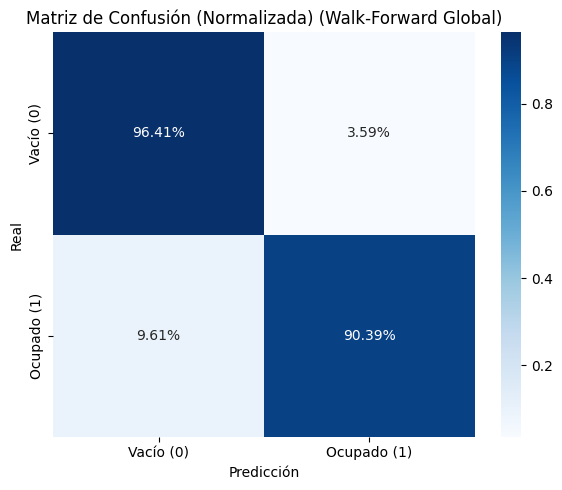

In [10]:
# 1. Cajas vacías para acumular los resultados reales y predichos de todos los meses
y_val_global = []
y_pred_global = []

# Guardar resultados de cada pliegue
for i, (train_idx, val_idx) in enumerate(folds):
    
    # --- E. Evaluación ---
    y_prob = modelo_xgb.predict_proba(X_val_tree)[:, 1]
    y_pred = modelo_xgb.predict(X_val_tree)
    
    # NUEVO: Guardamos las predicciones y los valores reales de este fold
    y_val_global.extend(y_val.values)
    y_pred_global.extend(y_pred)
    
    metricas = evaluate_classification(y_val, y_pred, y_prob, fold_name=f"Fold {i+1}")
    resultados_folds.append(metricas)

print("\nGenerando Matriz de Confusión Global")
plot_confusion_matrix(
    np.array(y_val_global), 
    np.array(y_pred_global), 
    title_suffix="(Walk-Forward Global)")

# 3. Feature importance

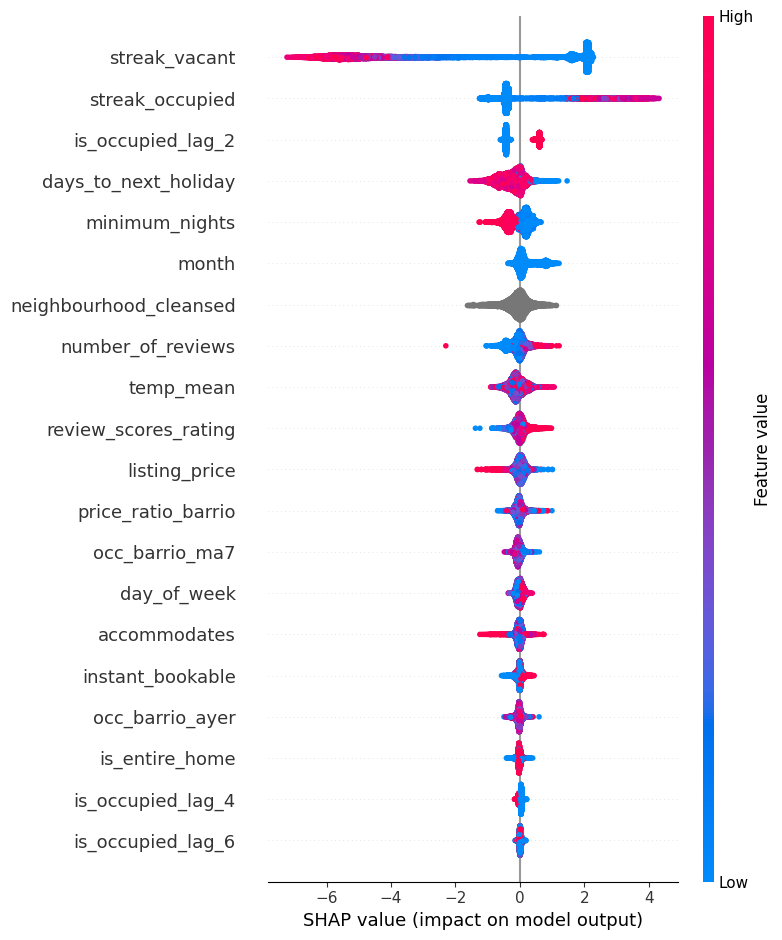

In [12]:
X_sample = X_val_tree.sample(10000, random_state=42)

explainer = shap.TreeExplainer(modelo_xgb)
shap_values = explainer(X_sample,check_additivity=False)

shap.summary_plot(shap_values.values, X_sample)

# VALIDACION DE QUE NO HAY DATA LEAKAGE FUTURO

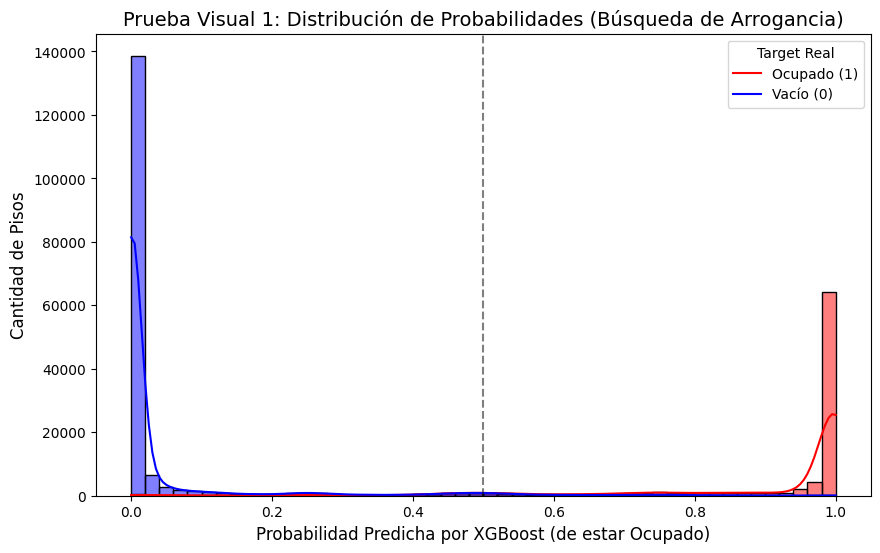

In [ ]:
plt.figure(figsize=(10, 6))
# Usamos y_val_global y y_pred_global (o los del último fold: y_val, y_prob)
sns.histplot(x=y_prob, hue=y_val, bins=50, kde=True, palette={0: 'blue', 1: 'red'})
plt.title('Prueba Visual 1: Distribución de Probabilidades (Búsqueda de Arrogancia)', fontsize=14)
plt.xlabel('Probabilidad Predicha por XGBoost (de estar Ocupado)', fontsize=12)
plt.ylabel('Cantidad de Pisos', fontsize=12)
plt.axvline(0.5, color='black', linestyle='--', alpha=0.5)
plt.legend(title='Target Real', labels=['Ocupado (1)', 'Vacío (0)'])
plt.show()

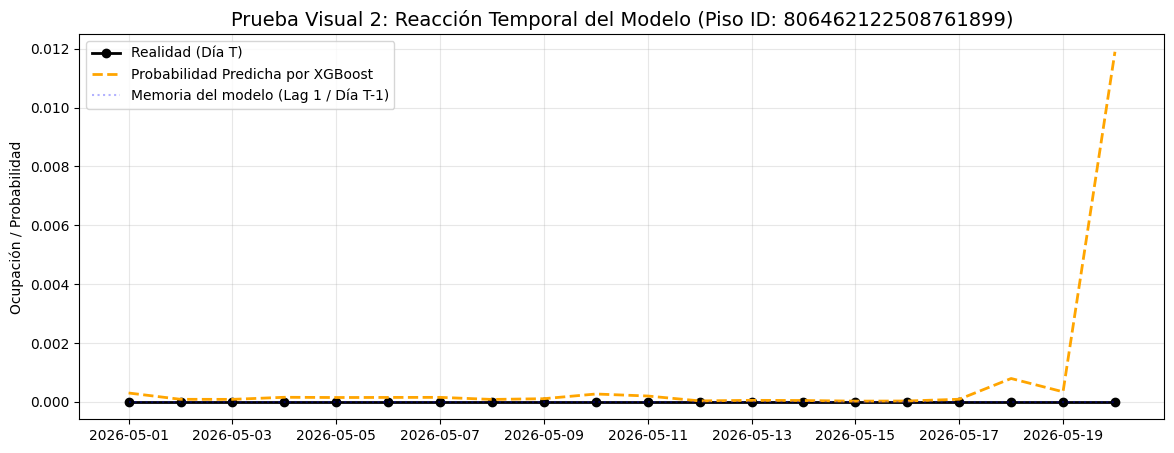

In [19]:
# Elegimos un piso aleatorio de los datos de validación
sample_id = df_processed.loc[val_idx, 'listing_id'].sample(1).values[0]

# Filtramos los datos de ese piso (usando el DataFrame en bruto para tener las fechas)
df_plot = df_processed[(df_processed['listing_id'] == sample_id) & (df_processed.index.isin(val_idx))].sort_values('date')

# Obtenemos las probabilidades predichas solo para este piso
# (Nota: Asegúrate de extraer las probabilidades que corresponden a este val_idx específico)
idx_mask = X_val_raw.index.isin(df_plot.index)
prob_piso = y_prob[idx_mask] 

plt.figure(figsize=(14, 5))
plt.plot(df_plot['date'], df_plot['is_occupied'], label='Realidad (Día T)', color='black', linewidth=2, marker='o')
plt.plot(df_plot['date'], prob_piso, label='Probabilidad Predicha por XGBoost', color='orange', linestyle='--', linewidth=2)
plt.plot(df_plot['date'], df_plot['is_occupied_lag_1'], label='Memoria del modelo (Lag 1 / Día T-1)', color='blue', alpha=0.3, linestyle=':')

plt.title(f'Prueba Visual 2: Reacción Temporal del Modelo (Piso ID: {sample_id})', fontsize=14)
plt.ylabel('Ocupación / Probabilidad')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

C:\Users\Yannis\AppData\Local\Temp\ipykernel_6184\1463139075.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=y_val, y=X_val_raw[col], ax=axes[i], palette='Set2')
C:\Users\Yannis\AppData\Local\Temp\ipykernel_6184\1463139075.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=y_val, y=X_val_raw[col], ax=axes[i], palette='Set2')
C:\Users\Yannis\AppData\Local\Temp\ipykernel_6184\1463139075.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=y_val, y=X_val_raw[col], ax=axes[i], palette='Set2')
C:\Users\Yannis\AppData\Local\Temp

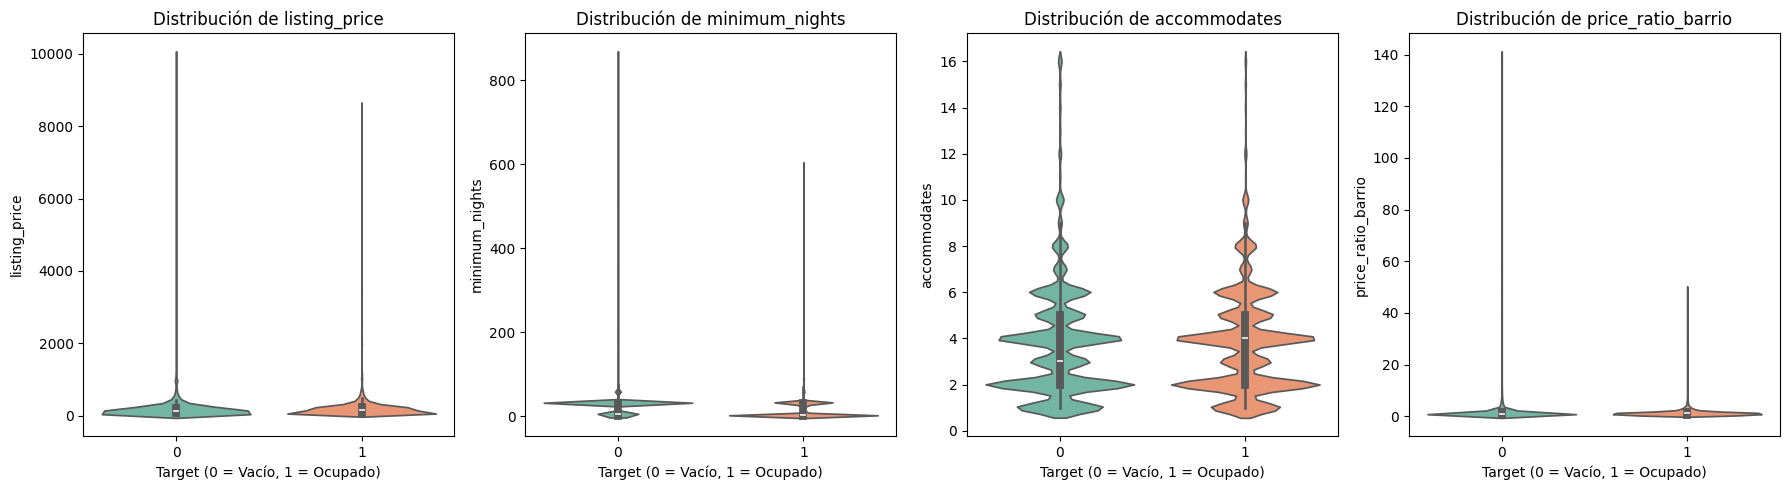

In [20]:
# Seleccionamos algunas variables continuas clave (que no sean los lags temporales directos)
cols_to_check = ['listing_price', 'minimum_nights', 'accommodates', 'price_ratio_barrio']

fig, axes = plt.subplots(1, len(cols_to_check), figsize=(18, 5))

for i, col in enumerate(cols_to_check):
    sns.violinplot(x=y_val, y=X_val_raw[col], ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel('Target (0 = Vacío, 1 = Ocupado)')
    
plt.tight_layout()
plt.show()

c:\Users\Yannis\anaconda3\envs\project3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Yannis\anaconda3\envs\project3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


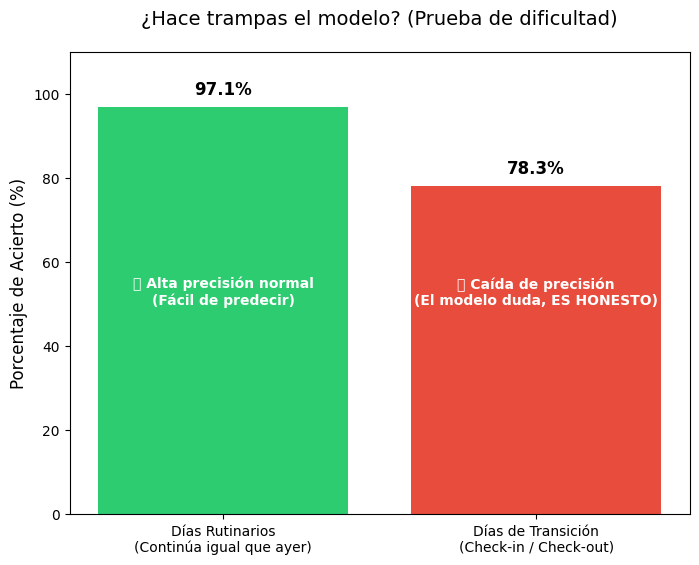

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# Recuperamos las fechas y los lags del último fold para evaluar
df_eval = df_processed.loc[val_idx, ['date', 'is_occupied_lag_1', 'is_occupied']].copy()
df_eval['prediccion'] = y_pred

# Detectamos cuándo hay un check-in o check-out (La realidad cambia respecto a ayer)
df_eval['es_cambio'] = df_eval['is_occupied'] != df_eval['is_occupied_lag_1']

# Calculamos el % de acierto en cada escenario
acierto_normales = accuracy_score(df_eval[~df_eval['es_cambio']]['is_occupied'], df_eval[~df_eval['es_cambio']]['prediccion'])
acierto_cambios = accuracy_score(df_eval[df_eval['es_cambio']]['is_occupied'], df_eval[df_eval['es_cambio']]['prediccion'])

# Gráfico
plt.figure(figsize=(8, 6))
bars = plt.bar(['Días Rutinarios\n(Continúa igual que ayer)', 'Días de Transición\n(Check-in / Check-out)'], 
        [acierto_normales * 100, acierto_cambios * 100], color=['#2ecc71', '#e74c3c'])

plt.title('¿Hace trampas el modelo? (Prueba de dificultad)', fontsize=14, pad=20)
plt.ylabel('Porcentaje de Acierto (%)', fontsize=12)
plt.ylim(0, 110)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Textos para negocio
plt.text(0, 50, "✅ Alta precisión normal\n(Fácil de predecir)", ha='center', color='white', fontweight='bold')
plt.text(1, 50, "📉 Caída de precisión\n(El modelo duda, ES HONESTO)", ha='center', color='white', fontweight='bold')

plt.show()

C:\Users\Yannis\AppData\Local\Temp\ipykernel_6184\2390528670.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acierto_diario = df_eval.groupby('date').apply(lambda x: accuracy_score(x['is_occupied'], x['prediccion']) * 100)


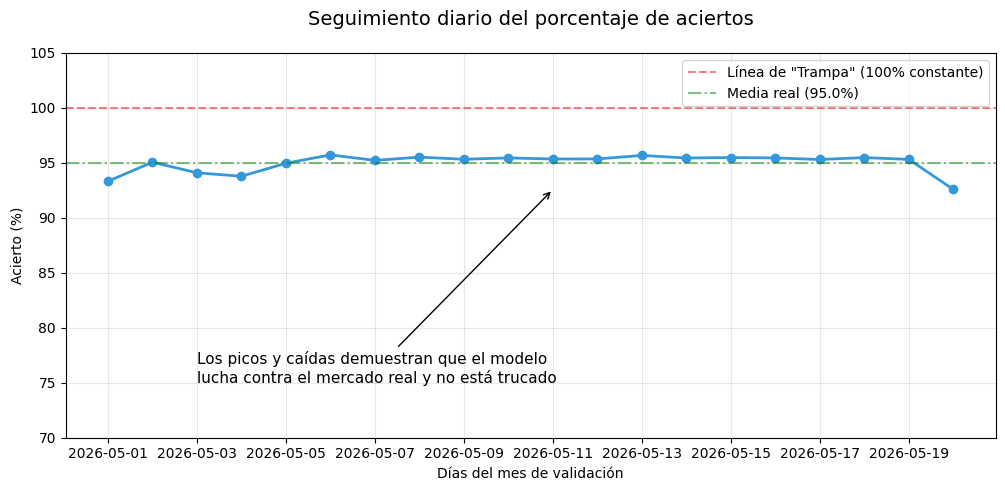

In [22]:
# Calcular el % de acierto por cada día del mes de validación
acierto_diario = df_eval.groupby('date').apply(lambda x: accuracy_score(x['is_occupied'], x['prediccion']) * 100)

plt.figure(figsize=(12, 5))
plt.plot(acierto_diario.index, acierto_diario.values, marker='o', color='#3498db', linewidth=2)

plt.axhline(100, color='red', linestyle='--', alpha=0.5, label='Línea de "Trampa" (100% constante)')
plt.axhline(acierto_diario.mean(), color='green', linestyle='-.', alpha=0.5, label=f'Media real ({acierto_diario.mean():.1f}%)')

plt.title('Seguimiento diario del porcentaje de aciertos', fontsize=14, pad=20)
plt.ylabel('Acierto (%)')
plt.xlabel('Días del mes de validación')
plt.ylim(70, 105)
plt.legend()
plt.grid(alpha=0.3)

# Textos para negocio
plt.annotate('Los picos y caídas demuestran que el modelo\nlucha contra el mercado real y no está trucado', 
             xy=(acierto_diario.index[len(acierto_diario)//2], acierto_diario.values.min()), 
             xytext=(acierto_diario.index[2], 75),
             arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=11)

plt.show()

C:\Users\Yannis\AppData\Local\Temp\ipykernel_6184\705213458.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acierto_diario = df_eval.groupby('date').apply(lambda x: accuracy_score(x['is_occupied'], x['prediccion']) * 100)


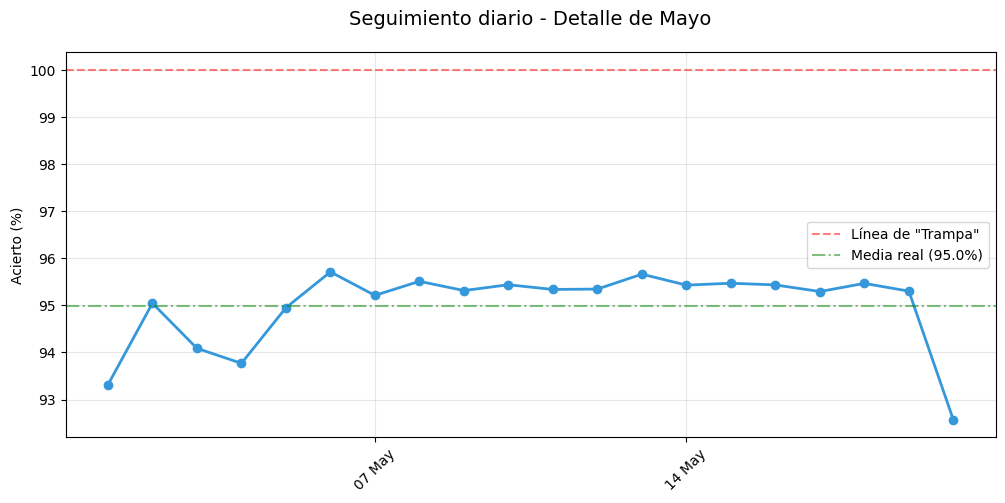

In [ ]:
import matplotlib.dates as mdates

acierto_diario = df_eval.groupby('date').apply(lambda x: accuracy_score(x['is_occupied'], x['prediccion']) * 100)

acierto_diario.index = pd.to_datetime(acierto_diario.index)

plt.figure(figsize=(12, 5))
plt.plot(acierto_diario.index, acierto_diario.values, marker='o', color='#3498db', linewidth=2)

ax = plt.gca()

# --- SOLUCIÓN: Mostrar etiquetas cada 7 días para que se vea el progreso ---
# Colocamos una marca cada 7 días para que el eje X no esté vacío
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7)) 

# Formato: Día y Mes (ej: 01 May) para que veas el avance dentro de Mayo
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b')) 

# Rotar las fechas para que no se solapen
plt.xticks(rotation=45)
# --------------------------------------------------------------------------

plt.axhline(100, color='red', linestyle='--', alpha=0.5, label='Línea de "Trampa"')
plt.axhline(acierto_diario.mean(), color='green', linestyle='-.', alpha=0.5, label=f'Media real ({acierto_diario.mean():.1f}%)')

plt.title('Seguimiento diario - Detalle de Mayo', fontsize=14, pad=20)
plt.ylabel('Acierto (%)')
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import accuracy_score
from pre_procesado.non_linear_pipeline import build_tree_pipeline
from utils_entrenamiento import evaluate_classification

print("============================================================")
print("🚀 ENTRENAMIENTO MAESTRO Y TEST DE DEGRADACIÓN (FEB-MAY)")
print("============================================================")

# 1. Definir el corte temporal: Train hasta Enero 2026, Test desde Febrero a Mayo 2026
df_processed['date'] = pd.to_datetime(df_processed['date'])
periodos = df_processed['date'].dt.to_period('M')

# Nuestro límite de entrenamiento (equivale al Train del Fold 1)
mes_corte = pd.Period('2026-01', freq='M')

mask_train = periodos <= mes_corte
train_idx_final = df_processed[mask_train].index
test_idx = df_processed[~mask_train].index

print(f"📅 Entrenando con histórico hasta: {mes_corte}")
print(f"📅 Evaluando predicciones de: Feb 2026 a May 2026")
print(f"   -> Train Final: {len(train_idx_final):,} filas")
print(f"   -> Test Largo:  {len(test_idx):,} filas")

# 2. Separar X e y
target = 'is_occupied'
cat_col_principal = 'neighbourhood_cleansed'

X_train_raw = df_processed.loc[train_idx_final].drop(columns=[target, 'listing_id', 'date'])
y_train = df_processed.loc[train_idx_final, target]

X_test_raw = df_processed.loc[test_idx].drop(columns=[target, 'listing_id', 'date'])
y_test = df_processed.loc[test_idx, target]

# 3. Limpieza y Pruning
columnas_basura = [
    'num_events', 'num_concerts', 'num_sports', 'num_festivals', 
    'total_attendance', 'max_attendance', 
    'is_missing_review_scores_rating', 'is_missing_review_scores_cleanliness',
    'is_missing_review_scores_location', 'is_missing_review_scores_value',
    'day_sin', 'day_cos', 'precipitation_mm'
]

for df in [X_train_raw, X_test_raw]:
    df.drop(columns=[c for c in columnas_basura if c in df.columns], inplace=True, errors='ignore')
    if 'room_type' in df.columns:
        df['is_entire_home'] = (df['room_type'] == 'Entire home/apt').astype('float64')
        df.drop(columns=['room_type'], inplace=True)
    if 'instant_bookable' in df.columns:
        df['instant_bookable'] = df['instant_bookable'].astype('float64')

# Casteo a float64
cols_to_float = [c for c in X_train_raw.columns if c != cat_col_principal]
X_train_raw[cols_to_float] = X_train_raw[cols_to_float].astype('float64')
X_test_raw[cols_to_float] = X_test_raw[cols_to_float].astype('float64')

# 4. Pipeline y Entrenamiento Maestro
print("\n🌲 Entrenando Pipeline Maestro...")
prep_tree = build_tree_pipeline(
    cat_col=cat_col_principal, target_col=target, lag_prefix='is_occupied_lag_', 
    top_k_lags=5, mi_sample_frac=0.3
)

X_train_tree = prep_tree.fit_transform(X_train_raw, y_train)
X_test_tree = prep_tree.transform(X_test_raw)

print("🤖 Entrenando XGBoost Maestro (Esto puede tardar unos segundos)...")
modelo_xgb_final = xgb.XGBClassifier(
    n_estimators=300, enable_categorical=True, tree_method='hist',
        device='cuda', random_state=42, n_jobs=-1
)
modelo_xgb_final.fit(X_train_tree, y_train)

# 5. Predicción en Test Largo
print("🔮 Prediciendo 4 meses hacia el futuro...")
y_prob_test = modelo_xgb_final.predict_proba(X_test_tree)[:, 1]
y_pred_test = modelo_xgb_final.predict(X_test_tree)

# Imprimir métricas agregadas del cuatrimestre
evaluate_classification(y_test, y_pred_test, y_prob_test, fold_name="TEST LARGO (4 MESES)")


📊 Generando gráfico de seguimiento a largo plazo...


C:\Users\Yannis\AppData\Local\Temp\ipykernel_6184\4068137912.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acierto_diario = df_eval_test.groupby('date').apply(lambda x: accuracy_score(x['is_occupied'], x['prediccion']) * 100)


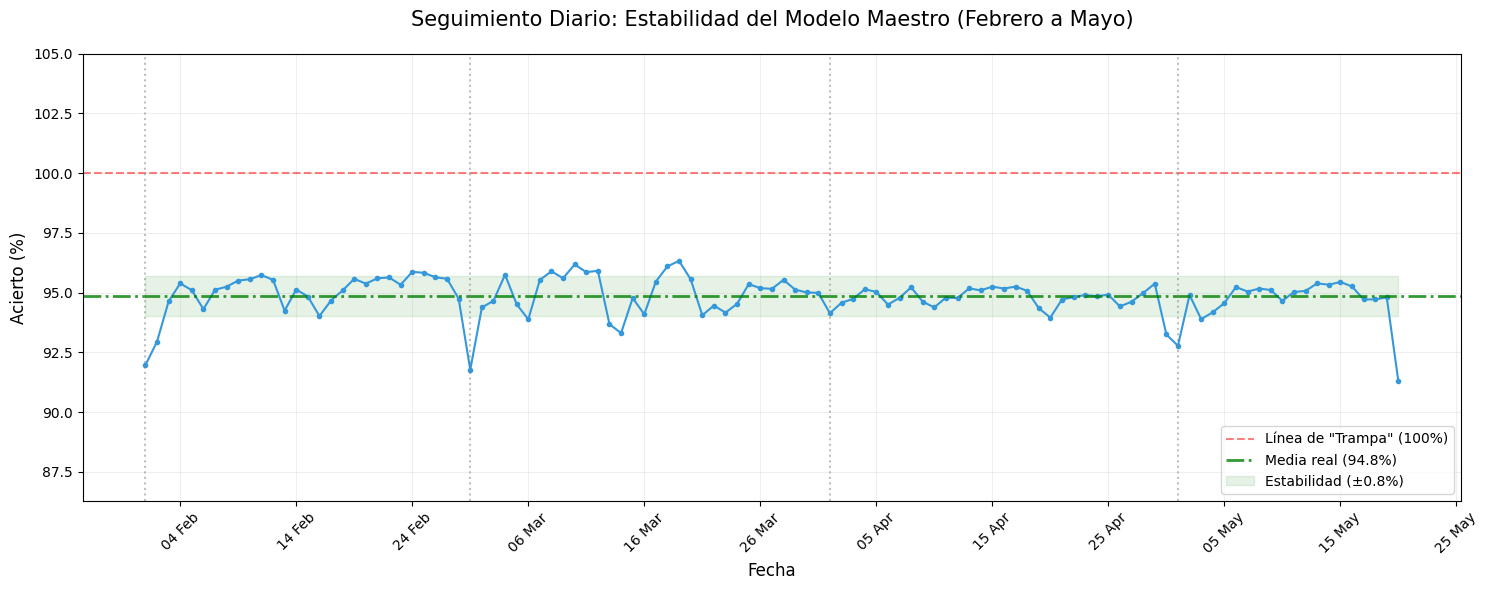

In [34]:
print("\n📊 Generando gráfico de seguimiento a largo plazo...")

# Preparar el DataFrame con las fechas
df_eval_test = df_processed.loc[test_idx, ['date', 'is_occupied']].copy()
df_eval_test['prediccion'] = y_pred_test

# Calcular acierto por día
acierto_diario = df_eval_test.groupby('date').apply(lambda x: accuracy_score(x['is_occupied'], x['prediccion']) * 100)
acierto_diario.index = pd.to_datetime(acierto_diario.index)

# Dibujar
plt.figure(figsize=(15, 6)) # Un poco más ancho porque son 4 meses
# Usamos un punto más fino y línea más fina por la densidad de días
plt.plot(acierto_diario.index, acierto_diario.values, marker='.', color='#3498db', linewidth=1.5)

ax = plt.gca()

# --- AJUSTE PARA 4 MESES ---
# Ponemos las etiquetas cada 10 días para que el eje X no sea un manchón negro
ax.xaxis.set_major_locator(mdates.DayLocator(interval=10)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b')) 
plt.xticks(rotation=45)

plt.axhline(100, color='red', linestyle='--', alpha=0.5, label='Línea de "Trampa" (100%)')
plt.axhline(acierto_diario.mean(), color='green', linestyle='-.', alpha=0.8, linewidth=2, label=f'Media real ({acierto_diario.mean():.1f}%)')
# Calcular media y desviación
media = acierto_diario.mean()
std_dev = acierto_diario.std()

# Dibujar la banda de desviación estándar (1 sigma hacia arriba y abajo)
plt.fill_between(acierto_diario.index, 
                 media - std_dev, 
                 media + std_dev, 
                 color='green', alpha=0.1, label=f'Estabilidad (±{std_dev:.1f}%)')

# Actualizar la leyenda para que incluya la desviación
plt.legend(loc='lower right')

# Resaltar inicio de cada mes
for month_start in pd.date_range(start='2026-02-01', end='2026-05-01', freq='MS'):
    plt.axvline(month_start, color='grey', linestyle=':', alpha=0.5)

plt.title('Seguimiento Diario: Estabilidad del Modelo Maestro (Febrero a Mayo)', fontsize=15, pad=20)
plt.ylabel('Acierto (%)', fontsize=12)
plt.xlabel('Fecha', fontsize=12)
plt.ylim(max(60, acierto_diario.min() - 5), 105) # Escala dinámica
plt.grid(alpha=0.2)
plt.legend(loc='lower right')
plt.tight_layout()

plt.show()

🙈 PRUEBA DE CEGUERA (ABLATION TEST SIN REENTRENAR)
💥 Destruyendo la información de: ['streak_occupied', 'streak_vacant', 'is_occupied_lag_1']...
🔮 Prediciendo sin las variables principales...

📊 RESULTADOS DEL IMPACTO:
   -> Accuracy Original (Con Lags/Rachas): 94.85%
   -> Accuracy Ciega (Sin Lags/Rachas):    48.58%
   📉 Caída de rendimiento: 46.27 puntos


C:\Users\Yannis\AppData\Local\Temp\ipykernel_6184\154037612.py:46: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acierto_diario_cego = df_eval_cego.groupby('date').apply(lambda x: accuracy_score(x['is_occupied'], x['pred_cega']) * 100)


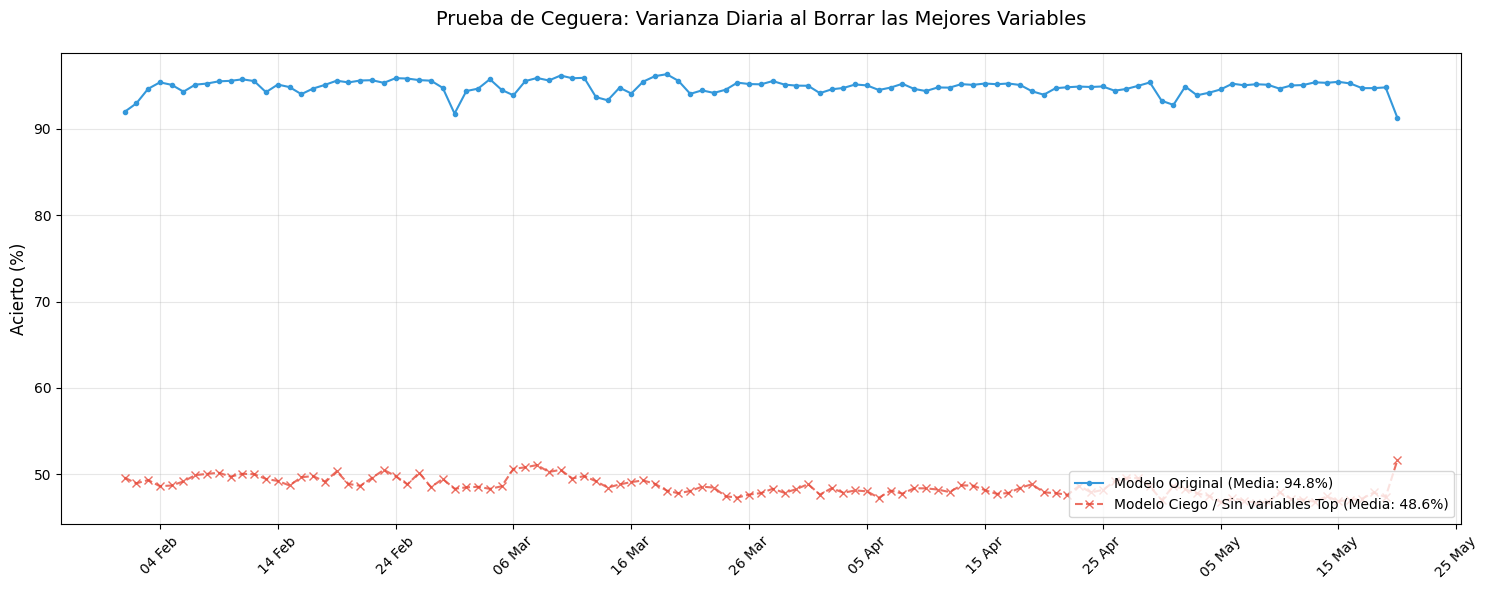


⚖️ VEREDICTO AUTOMÁTICO:
   -> Desviación estándar diaria del modelo ciego: 1.06%
   ✅ PRUEBA SUPERADA: La precisión se ha desplomado y la varianza ha subido. Las variables temporales eran legítimamente buenas y no hay Leakage oculto.


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import accuracy_score

print("============================================================")
print("🙈 PRUEBA DE CEGUERA (ABLATION TEST SIN REENTRENAR)")
print("============================================================")

# 1. Hacemos una copia exacta del Test Set ya preprocesado
X_test_cego = X_test_tree.copy()

# 2. Definimos las variables "Top" que vamos a destruir (Las reinas del SHAP)
variables_top = ['streak_occupied', 'streak_vacant', 'is_occupied_lag_1']

print(f"💥 Destruyendo la información de: {variables_top}...")

# 3. "Borrado virtual": Mezclamos los valores al azar (Permutación) 
# Esto destruye la relación de la variable con la realidad sin cambiar la forma del DataFrame
np.random.seed(42)
for col in variables_top:
    if col in X_test_cego.columns:
        # Barajamos la columna para que sea ruido puro
        X_test_cego[col] = np.random.permutation(X_test_cego[col].values)

# 4. Hacemos que el modelo Maestro (ya entrenado) intente predecir a ciegas
print("🔮 Prediciendo sin las variables principales...")
y_pred_cego = modelo_xgb_final.predict(X_test_cego)

# 5. Calculamos la precisión global nueva vs la original
acc_original = accuracy_score(y_test, y_pred_test) * 100
acc_cega = accuracy_score(y_test, y_pred_cego) * 100

print("\n📊 RESULTADOS DEL IMPACTO:")
print(f"   -> Accuracy Original (Con Lags/Rachas): {acc_original:.2f}%")
print(f"   -> Accuracy Ciega (Sin Lags/Rachas):    {acc_cega:.2f}%")
print(f"   📉 Caída de rendimiento: {acc_original - acc_cega:.2f} puntos")

# =============================================================================
# 6. GRÁFICO: COMPARATIVA DE VARIANZA DIARIA
# =============================================================================

# Calcular acierto diario del modelo ciego
df_eval_cego = pd.DataFrame({'date': df_processed.loc[test_idx, 'date'], 'is_occupied': y_test, 'pred_cega': y_pred_cego})
acierto_diario_cego = df_eval_cego.groupby('date').apply(lambda x: accuracy_score(x['is_occupied'], x['pred_cega']) * 100)
acierto_diario_cego.index = pd.to_datetime(acierto_diario_cego.index)

# Dibujar la comparativa
plt.figure(figsize=(15, 6))

# Línea del modelo original (La estable que vimos antes)
plt.plot(acierto_diario.index, acierto_diario.values, marker='.', color='#3498db', linewidth=1.5, label=f'Modelo Original (Media: {acierto_diario.mean():.1f}%)')

# Línea del modelo "Ciego"
plt.plot(acierto_diario_cego.index, acierto_diario_cego.values, marker='x', color='#e74c3c', linewidth=1.5, linestyle='--', alpha=0.8, label=f'Modelo Ciego / Sin variables Top (Media: {acierto_diario_cego.mean():.1f}%)')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=10)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b')) 
plt.xticks(rotation=45)

plt.title('Prueba de Ceguera: Varianza Diaria al Borrar las Mejores Variables', fontsize=14, pad=20)
plt.ylabel('Acierto (%)', fontsize=12)
plt.grid(alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()

plt.show()

# Imprimir el veredicto automático basado en tu lógica
desviacion_cega = acierto_diario_cego.std()
print("\n⚖️ VEREDICTO AUTOMÁTICO:")
print(f"   -> Desviación estándar diaria del modelo ciego: {desviacion_cega:.2f}%")

if acc_cega > 90:
    print("   ❌ ALERTA ROJA: La precisión sigue altísima (Por encima del 90%). Revisa el pipeline, hay una variable secundaria haciendo Data Leakage.")
else:
    print("   ✅ PRUEBA SUPERADA: La precisión se ha desplomado y la varianza ha subido. Las variables temporales eran legítimamente buenas y no hay Leakage oculto.")

In [36]:
import pandas as pd
import numpy as np

print("============================================================")
print("🕵️‍♂️ AUDITORÍA DE LAGS: INSPECCIÓN DE DESFASE TEMPORAL")
print("============================================================")

# Asegurarnos de que las fechas están ordenadas
df_processed = df_processed.sort_values(['listing_id', 'date'])

# 1. INSPECCIÓN VISUAL: Elegir un piso con transiciones para que el efecto sea evidente
pisos_con_cambios = df_processed.groupby('listing_id')['is_occupied'].nunique()
pisos_candidatos = pisos_con_cambios[pisos_con_cambios > 1].index

# Tomamos uno al azar
np.random.seed(42) # Semilla fija para reproducibilidad
sample_id = np.random.choice(pisos_candidatos)

print(f"\n🔍 Inspeccionando el piso ID: {sample_id}")

df_sample = df_processed[df_processed['listing_id'] == sample_id]
columnas_ver = ['date', 'is_occupied', 'is_occupied_lag_1']

# Encontramos el índice donde cambia el estado (Check-in o Check-out)
cambios = df_sample['is_occupied'].diff().abs()
if cambios.sum() > 0:
    # Cogemos el primer cambio que no sea NaN
    idx_cambio = cambios[cambios > 0].index[0]
    pos = df_sample.index.get_loc(idx_cambio)
    # Mostramos 3 días antes y 3 días después del cambio
    inicio = max(0, pos - 3)
    fin = min(len(df_sample), pos + 4)
    vista = df_sample.iloc[inicio:fin][columnas_ver]
else:
    vista = df_sample[columnas_ver].head(7)

print("\n📅 Vista de 7 días (Fíjate cómo la columna lag_1 va un día por detrás de is_occupied):")
print(vista.to_string(index=False))

print("\n============================================================")
print("🧮 PRUEBA MATEMÁTICA GLOBAL EN TODO EL DATASET")
print("============================================================")

# Recreamos el lag esperado reconstruyendo el shift
lag_esperado = df_processed.groupby('listing_id')['is_occupied'].shift(1)

# Filtramos los nulos (el primer día de cada piso no tiene lag)
filas_validas = df_processed['is_occupied_lag_1'].notna() & lag_esperado.notna()

# Comparamos toda la matriz de golpe
diferencias = (df_processed.loc[filas_validas, 'is_occupied_lag_1'] != lag_esperado[filas_validas]).sum()

print(f"Filas evaluadas: {filas_validas.sum():,}")
print(f"Errores encontrados de desfase: {diferencias}")

if diferencias == 0:
    print("\n✅ VEREDICTO: PERFECTO. Matemáticamente demostrado: Tus lags están perfectamente calculados. Cero Data Leakage en la variable más importante.")
else:
    print(f"\n❌ ALERTA: Hay {diferencias} filas donde el lag no coincide con el día anterior. Revisa tu preprocesamiento original.")

🕵️‍♂️ AUDITORÍA DE LAGS: INSPECCIÓN DE DESFASE TEMPORAL

🔍 Inspeccionando el piso ID: 923975451521480887

📅 Vista de 7 días (Fíjate cómo la columna lag_1 va un día por detrás de is_occupied):
      date  is_occupied  is_occupied_lag_1
2025-09-14            1               <NA>
2025-09-15            0                  1
2025-09-16            0                  0
2025-09-17            0                  0
2025-09-18            0                  0

🧮 PRUEBA MATEMÁTICA GLOBAL EN TODO EL DATASET
Filas evaluadas: 3,638,141
Errores encontrados de desfase: 0

✅ VEREDICTO: PERFECTO. Matemáticamente demostrado: Tus lags están perfectamente calculados. Cero Data Leakage en la variable más importante.
